# Analyse Kiprix — Groupe SCP2
Notebook d'exploration des données scrapées depuis kiprix.com.

In [19]:
from pathlib import Path
import pandas as pd
import re

data_path = Path('../data/raw/kiprix_gp.json')
if not data_path.exists():
    raise FileNotFoundError(f'Fichier introuvable: {data_path.resolve()}')

df = pd.read_json(data_path)
print(f'Produits chargés: {len(df)}')
df.head()

Produits chargés: 120


,name,url,price_france,price_dom,difference,quantity_value,quantity_unit,unit_reference,unit_price_france,unit_price_dom,territory,territory_name
0,Amandes naturelles Natur & Bon Non salées -180g,https://www.kiprix.com/fr-gp/produit/8706,"2,14 €","4,95 €","+ 131,31%",180.0,g,€/kg,11.89,27.5,gp,Guadeloupe
1,Cacahuètes grillées salées PRIX MINI,https://www.kiprix.com/fr-gp/produit/53554,"0,76 €","1,46 €","+ 92,11%",NaN,NaN,NaN,NaN,NaN,gp,Guadeloupe
2,U\nMaïs doux en grains sans sucre ajouté - Boîte,https://www.kiprix.com/fr-gp/produit/54412,"0,99 €","1,10 €","+ 11,11%",NaN,NaN,NaN,NaN,NaN,gp,Guadeloupe
3,U\nNoix de cajou romarin poivre paquet de,https://www.kiprix.com/fr-gp/produit/53560,"2,38 €","2,79 €","+ 17,23%",NaN,NaN,NaN,NaN,NaN,gp,Guadeloupe
4,Lait démaquillant Diadermine Hydratant - 200ml,https://www.kiprix.com/fr-gp/produit/21201,"2,44 €","5,20 €","+ 113,11%",200.0,ml,€/L,12.20,26.0,gp,Guadeloupe


In [20]:
def parse_diff(value):
    match = re.search(r'([+-]?\s*\d+[\d\s.,]*)\s*%', str(value))
    if not match:
        return None
    cleaned = match.group(1).replace(' ', '').replace('\u00a0', '').replace(',', '.')
    try:
        return float(cleaned)
    except ValueError:
        return None

df['difference_numeric'] = df['difference'].apply(parse_diff)
df['price_france_num'] = pd.to_numeric(
    df['price_france'].astype(str).str.replace('€', '', regex=False).str.replace(' ', '', regex=False).str.replace(',', '.', regex=False),
    errors='coerce'
)
df['price_dom_num'] = pd.to_numeric(
    df['price_dom'].astype(str).str.replace('€', '', regex=False).str.replace(' ', '', regex=False).str.replace(',', '.', regex=False),
    errors='coerce'
)

df[['difference_numeric', 'price_france_num', 'price_dom_num']].describe()

,difference_numeric,price_france_num,price_dom_num
count,110.000000,120.000000,120.000000
mean,44.149545,2.828500,3.779250
std,40.471971,4.866079,6.012807
min,2.510000,0.600000,0.850000
25%,18.102500,1.567500,2.050000
50%,37.910000,2.125000,2.725000
75%,56.900000,2.707500,3.562500
max,323.390000,42.900000,49.000000


In [21]:
summary = {
    'total_produits': int(len(df)),
    'moyenne_ecart_pct': float(df['difference_numeric'].dropna().mean()) if df['difference_numeric'].notna().any() else 0.0,
    'mediane_ecart_pct': float(df['difference_numeric'].dropna().median()) if df['difference_numeric'].notna().any() else 0.0,
    'max_ecart_pct': float(df['difference_numeric'].dropna().max()) if df['difference_numeric'].notna().any() else 0.0,
    'min_ecart_pct': float(df['difference_numeric'].dropna().min()) if df['difference_numeric'].notna().any() else 0.0,
}
summary

{'total_produits': 120,
 'moyenne_ecart_pct': 44.14954545454545,
 'mediane_ecart_pct': 37.91,
 'max_ecart_pct': 323.39,
 'min_ecart_pct': 2.51}

In [22]:
top5_dom = df.dropna(subset=['price_dom_num']).nlargest(5, 'price_dom_num')[['name', 'territory', 'price_dom', 'difference']]
top5_dom

,name,territory,price_dom,difference
89,BRUDER - Camion pompier MAN TGA - Dès 3,gp,"49,00 €","+ 40,04%"
98,U MAISON\nHousse de couette bicolore 260x240cm...,gp,"47,71 €","+ 11,21%"
90,U\nPlat En Céramique Four Et,gp,"10,80 €","+ 18,94%"
12,U\nPistaches grillées et salées,gp,"6,95 €","+ 57,95%"
88,Mini Bâtonnets glacés Deluxe Chocolat MAGNUM,gp,"6,90 €","+ 54,71%"


In [23]:
# Analyse des prix unitaires (si disponibles dans le JSON)
if {'unit_price_france', 'unit_price_dom', 'unit_reference'}.issubset(df.columns):
    unit_df = df.dropna(subset=['unit_price_dom'])[[
        'name', 'territory', 'unit_reference', 'unit_price_france', 'unit_price_dom'
    ]].copy()
    print(f"Produits avec prix unitaire: {len(unit_df)}")
    display(unit_df.head(10))
    print('Moyenne prix unitaire France :', round(unit_df['unit_price_france'].dropna().mean(), 2))
    print('Moyenne prix unitaire DOM    :', round(unit_df['unit_price_dom'].dropna().mean(), 2))
else:
    print('Colonnes de prix unitaires absentes. Regénère le JSON avec le scraper mis à jour.')

Produits avec prix unitaire: 31


,name,territory,unit_reference,unit_price_france,unit_price_dom
0,Amandes naturelles Natur & Bon Non salées -180g,gp,€/kg,11.89,27.50
4,Lait démaquillant Diadermine Hydratant - 200ml,gp,€/L,12.20,26.00
9,Camembert Le Rustique 250g,gp,€/kg,9.40,14.20
25,Purée de tomate Panzani Tomacouli ail & herbes...,gp,€/kg,2.72,4.10
32,Lait de coco Suzi Wan 500ml,gp,€/L,5.76,11.00
38,Fromage Tartare Ail et fines herbes - 150g,gp,€/kg,13.27,23.00
39,Camembert portion Président 8 pièces - 240g,gp,€/kg,13.42,16.46
45,Crème dessert La Laitière Pot de crème caramel...,gp,€/kg,24.30,37.90
50,U\nMoutarde mi-forte bocal atlas de 37cl,gp,€/L,3.65,6.73
53,Flocons d'avoine complet Bjorg bio - 900g,gp,€/kg,3.82,5.33


Moyenne prix unitaire France : 13.12
Moyenne prix unitaire DOM    : 18.95


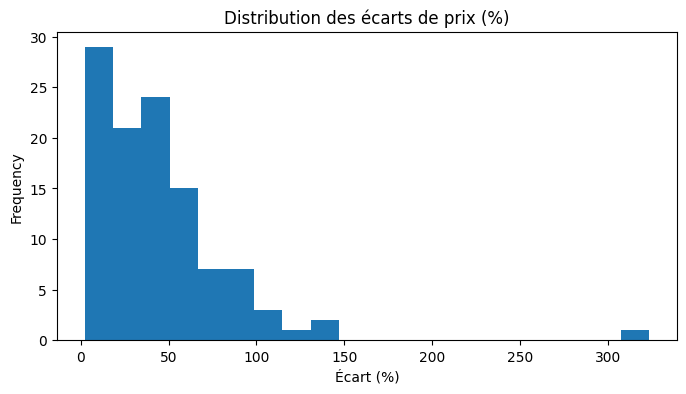

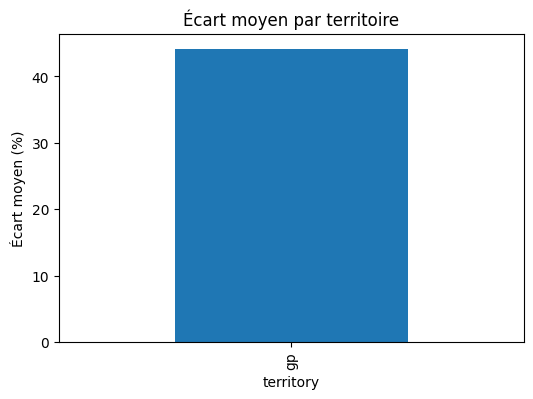

In [24]:
try:
    import matplotlib.pyplot as plt

    ax = df['difference_numeric'].dropna().plot(kind='hist', bins=20, title='Distribution des écarts de prix (%)', figsize=(8, 4))
    ax.set_xlabel('Écart (%)')
    plt.show()

    if 'territory' in df.columns:
        ax2 = df.groupby('territory')['difference_numeric'].mean().plot(kind='bar', title='Écart moyen par territoire', figsize=(6, 4))
        ax2.set_ylabel('Écart moyen (%)')
        plt.show()
except ModuleNotFoundError:
    print('matplotlib non installé. Installe-le avec: pip install matplotlib')